In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')


sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# Selección de dataset

df = pd.read_csv("dataset.csv") 

# vista
print(f"Dimensiones del dataset: {df.shape}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Dimensiones del dataset: (100000, 32)
Filas: 100,000 | Columnas: 32


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.70,Japan,6.19,6.60,22.50,19.30,16,3,0,0.00,32,0,6592,0,4.40,10.70,Morning,Healthy,63,0,0,20.10,1.84,Autumn,Weekday,73.40,Healthy,0
1,2,55,Female,Software Engineer,22.00,USA,8.32,6.90,26.90,14.90,17,4,0,0.00,33,1,10111,8,4.00,3.00,Neutral,Healthy,52,1,0,18.00,0.13,Winter,Weekend,99.40,Healthy,1
2,3,42,Male,Nurse,25.00,India,3.74,1.00,20.20,16.20,26,4,0,2.00,89,1,9222,28,7.80,3.60,Neutral,Both,72,0,1,17.90,1.67,Spring,Weekend,2.50,Severe,0
3,4,37,Female,Student,29.50,India,6.79,6.40,17.70,17.70,13,4,0,1.00,52,1,9190,40,4.90,6.70,Morning,Healthy,71,0,0,19.10,2.37,Summer,Weekend,67.80,Healthy,0
4,5,23,Male,Lawyer,23.60,Spain,5.02,3.20,23.30,18.30,30,5,40,0.00,72,0,4273,0,7.40,10.40,Neutral,Healthy,71,0,0,19.70,1.26,Summer,Weekday,38.10,Mild,0


# Hipotesis a evaluar
1. **H1:** Correlación entre duración y calidad subjetiva del sueño
2. **H2:** Impacto de la ocupación (alta vs. baja demanda) sobre los indicadores de sueño
3. **H3:** Relación entre BMI (Índice de Masa Corporal) y porcentaje de sueño profundo
4. **H4:** Efecto de la edad sobre el porcentaje de sueño REM
5. **H5:** Existencia de "durmientes eficientes" y sus características distintivas

In [3]:
# Información general: tipos de datos y nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  str    
 3   occupation                   100000 non-null  str    
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  str    
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  alcohol_uni

In [4]:
# Estadísticos descriptivos de variables numéricas
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,50000.50,34.71,26.29,6.42,4.87,20.24,20.25,19.84,3.35,38.85,0.60,63.54,0.45,7496.86,14.94,5.73,7.13,66.57,0.56,0.08,20.54,1.20,59.23,0.39
std,28867.66,11.04,4.48,1.27,1.51,3.41,4.25,7.58,1.92,69.40,1.06,44.55,0.50,3460.42,21.39,1.62,3.48,7.23,0.50,0.28,2.90,0.79,22.25,0.49
min,1.00,18.00,16.00,3.00,1.00,10.00,5.00,1.00,0.00,0.00,0.00,2.00,0.00,500.00,0.00,1.00,0.00,45.00,0.00,0.00,15.00,-1.00,0.00,0.00
25%,25000.75,26.00,23.20,5.53,3.80,18.00,17.40,14.00,2.00,0.00,0.00,30.00,0.00,5045.00,0.00,4.80,4.70,62.00,0.00,0.00,18.50,0.67,44.20,0.00
50%,50000.50,33.00,26.30,6.36,4.90,20.30,20.30,19.00,3.00,0.00,0.00,51.00,0.00,7442.00,0.00,5.80,7.40,67.00,1.00,0.00,20.50,1.20,60.40,0.00
75%,75000.25,42.00,29.30,7.27,6.00,22.60,23.20,25.00,5.00,80.00,1.00,84.00,1.00,9887.00,30.00,6.80,9.70,71.00,1.00,0.00,22.50,1.74,75.80,1.00
max,100000.00,69.00,45.00,10.50,10.00,30.00,30.00,58.00,8.00,400.00,6.00,180.00,1.00,20000.00,116.00,10.00,18.00,99.00,1.00,1.00,28.00,3.00,100.00,1.00


In [58]:
# Variables categóricas: cardinalidad y top valores
print("Categóricas:")
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}: {df[col].nunique()} valores únicos")
    print(df[col].value_counts().head())

Categóricas:

gender: 3 valores únicos
gender
Female    50203
Male      47823
Other      1974
Name: count, dtype: int64

occupation: 12 valores únicos
occupation
Student              14851
Software Engineer    12068
Nurse                10073
Manager               8101
Teacher               8047
Name: count, dtype: int64

country: 15 valores únicos
country
USA       20050
India     17840
Japan      8089
UK         8024
Brazil     7146
Name: count, dtype: int64

chronotype: 3 valores únicos
chronotype
Neutral    45396
Evening    29643
Morning    24961
Name: count, dtype: int64

mental_health_condition: 4 valores únicos
mental_health_condition
Healthy       69993
Anxiety       15134
Depression     9854
Both           5019
Name: count, dtype: int64

season: 4 valores únicos
season
Summer    25121
Spring    25110
Autumn    24892
Winter    24877
Name: count, dtype: int64

day_type: 2 valores únicos
day_type
Weekday    71428
Weekend    28572
Name: count, dtype: int64

sleep_disorder_risk: 4 

## validación de datos


In [59]:
# Valores nulos por columna
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos en el dataset")

Valores nulos por columna:
No hay valores nulos en el dataset


In [60]:
# Duplicados completos y por identificador
print(f"Filas completamente duplicadas: {df.duplicated().sum()}")
print(f"person_id duplicados: {df.person_id.duplicated().sum()}")

Filas completamente duplicadas: 0
person_id duplicados: 0


In [81]:
# Validación de rangos lógicos
print("Validación de rangos esperados:")
print(f"  Edad: {df.age.min()} - {df.age.max()} años")
print(f"  BMI: {df.bmi.min():.2f} - {df.bmi.max():.2f}")
print(f"  Sueño hrs: {df.sleep_duration_hrs.min():.2f} - {df.sleep_duration_hrs.max():.2f}")
print(f"  Calidad: {df.sleep_quality_score.min()} - {df.sleep_quality_score.max()}")
print(f"  REM%: {df.rem_percentage.min():.2f} - {df.rem_percentage.max():.2f}")
print(f"  Deep%: {df.deep_sleep_percentage.min():.2f} - {df.deep_sleep_percentage.max():.2f}")

# Coherencia: % REM + % sueño profundo no debería superar 100%
df["fases_suma"] = df.rem_percentage + df.deep_sleep_percentage
inconsistentes = (df.fases_suma > 100).sum()
print(f"\nFilas con REM% + Deep% > 100%: {inconsistentes}")
df.drop(columns="fases_suma", inplace=True)

Validación de rangos esperados:
  Edad: 18 - 69 años
  BMI: 16.00 - 45.00
  Sueño hrs: 3.00 - 10.50
  Calidad: 1.0 - 10.0
  REM%: 10.00 - 30.00
  Deep%: 5.00 - 30.00

Filas con REM% + Deep% > 100%: 0


In [62]:
# Estandarizar texto en categóricas (espacios, capitalización)
for col in ['gender', 'occupation', 'country']:
    df[col] = df[col].astype(str).str.strip()

# Tipos finales
print("Tipos de datos después de limpieza:")
print(df.dtypes)

Tipos de datos después de limpieza:
person_id                         int64
age                               int64
gender                              str
occupation                          str
bmi                             float64
country                             str
sleep_duration_hrs              float64
sleep_quality_score             float64
rem_percentage                  float64
deep_sleep_percentage           float64
sleep_latency_mins                int64
wake_episodes_per_night           int64
caffeine_mg_before_bed            int64
alcohol_units_before_bed        float64
screen_time_before_bed_mins       int64
exercise_day                      int64
steps_that_day                    int64
nap_duration_mins                 int64
stress_score                    float64
work_hours_that_day             float64
chronotype                          str
mental_health_condition             str
heart_rate_resting_bpm            int64
sleep_aid_used                    int64
shif

**Resultado:** El dataset no presenta valores nulos ni duplicados. Los rangos de todas las variables son lógicamente coherentes y no se detectaron filas donde REM% + Deep% > 100%. 

### Creamos variables derivadas para el análisis y que permiten responder hipótesis específicas.

In [83]:
# Minutos absolutos de sueño profundo y REM (variables clave para H5)
df["deep_sleep_min"] = (df.sleep_duration_hrs * 60) * (df.deep_sleep_percentage / 100)
df["rem_sleep_min"] = (df.sleep_duration_hrs * 60) * (df.rem_percentage / 100)

# Grupos de edad
df["age_group"] = pd.cut(df.age,
    bins=[0, 25, 40, 60, 100],
    labels=["18-25", "26-40", "41-60", "60+"])

# Categoría de BMI (estándar OMS)
df["bmi_category"] = pd.cut(df.bmi,
    bins=[0, 18.5, 25, 30, 100],
    labels=["Bajo peso", "Normal", "Sobrepeso", "Obesidad"])

# Categoría de duración del sueño (National Sleep Foundation)
df["sleep_category"] = pd.cut(df.sleep_duration_hrs,
    bins=[0, 6, 9, 24],
    labels=["Insuficiente (<6h)", "Recomendado (6-9h)", "Excesivo (>9h)"])

# H2 : Impacto de la ocupación en el sueño
alta_demanda = ["Doctor", "Nurse", "Manager"]
demanda_media = ["Software Engineer", "Lawyer", "Sales", "Driver"]
baja_demanda = ["Teacher", "Retired", "Homemaker", "Freelancer", "Student"]

def clasificar_demanda(occ):
    if occ in alta_demanda: return "Alta demanda"
    elif occ in demanda_media: return "Demanda media"
    else: return "Baja demanda"

df["demanda_laboral"] = df.occupation.apply(clasificar_demanda)

print("Variables derivadas creadas con éxito:")
print(df[['deep_sleep_min', 'age_group', 'bmi_category', 'sleep_category', 'demanda_laboral']].head())

Variables derivadas creadas con éxito:
   deep_sleep_min age_group bmi_category      sleep_category demanda_laboral
0           71.68     26-40    Sobrepeso  Recomendado (6-9h)   Demanda media
1           74.38     41-60       Normal  Recomendado (6-9h)   Demanda media
2           36.35     41-60       Normal  Insuficiente (<6h)    Alta demanda
3           72.11     26-40    Sobrepeso  Recomendado (6-9h)    Baja demanda
4           55.12     18-25       Normal  Insuficiente (<6h)   Demanda media


###  Distribuciones de variables numéricas (3 histogramas con KDE)

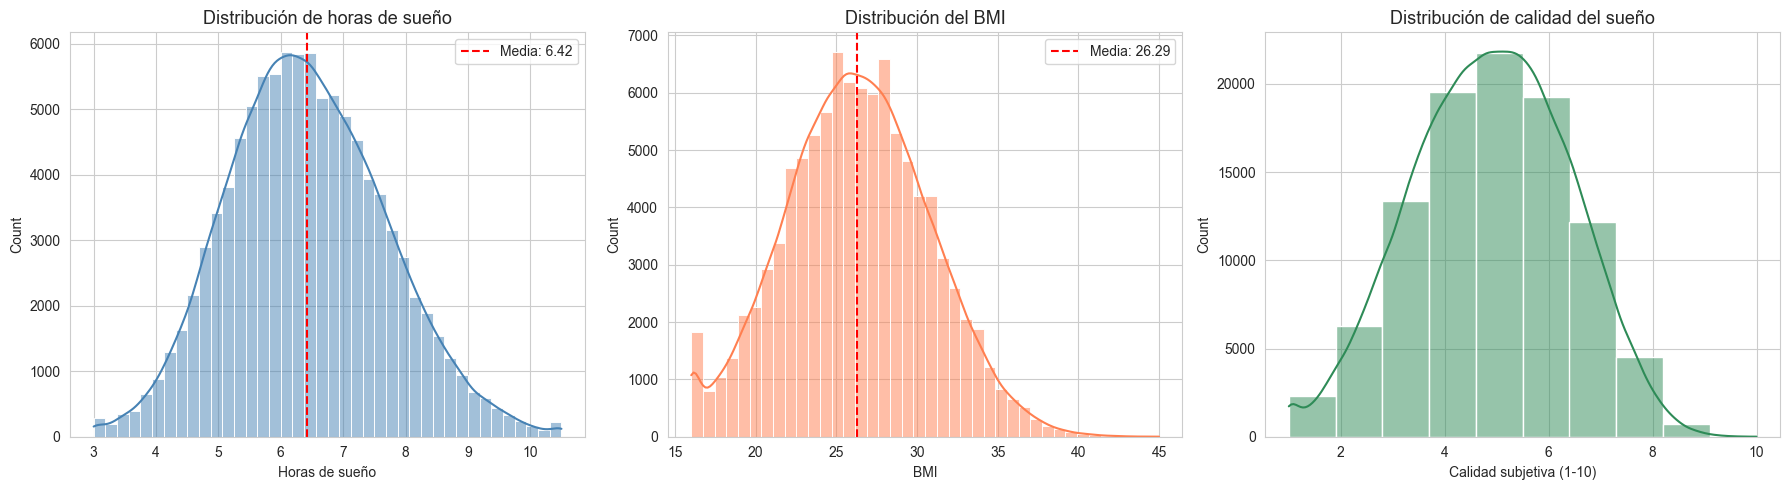

In [ ]:
# 3 HISTOGRAMAS CON KDE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df.sleep_duration_hrs, kde=True, ax=axes[0], color="steelblue", bins=40)
axes[0].set_title("Distribución de horas de sueño", fontsize=13)
axes[0].axvline(df.sleep_duration_hrs.mean(), color='red', linestyle='--',
                label=f'Media: {df.sleep_duration_hrs.mean():.2f}')
axes[0].set_xlabel("Horas de sueño")
axes[0].legend()

sns.histplot(df.bmi, kde=True, ax=axes[1], color="coral", bins=40)
axes[1].set_title("Distribución del BMI", fontsize=13)
axes[1].axvline(df.bmi.mean(), color='red', linestyle='--',
                label=f'Media: {df.bmi.mean():.2f}')
axes[1].set_xlabel("BMI")
axes[1].legend()

sns.histplot(df.sleep_quality_score, kde=True, ax=axes[2], color="seagreen", bins=10)
axes[2].set_title("Distribución de calidad del sueño", fontsize=13)
axes[2].set_xlabel("Calidad subjetiva (1-10)")

plt.tight_layout()
plt.show()

### Detección de outliers (método IQR)

In [65]:
# Detección de outliers con método del rango intercuartílico (IQR)
def detectar_outliers(serie, nombre):
    Q1, Q3 = serie.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    inf, sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = serie[(serie < inf) | (serie > sup)]
    return {'variable': nombre, 'n_outliers': len(outliers),
            '%': round(len(outliers)/len(serie)*100, 2),
            'limite_inf': round(inf, 2), 'limite_sup': round(sup, 2)}

resultados = [detectar_outliers(df[v], v) for v in
              ['bmi', 'sleep_duration_hrs', 'rem_percentage', 'deep_sleep_percentage']]
pd.DataFrame(resultados)

,variable,n_outliers,%,limite_inf,limite_sup
0,bmi,341,0.34,14.05,38.45
1,sleep_duration_hrs,545,0.55,2.92,9.88
2,rem_percentage,778,0.78,11.10,29.50
3,deep_sleep_percentage,402,0.40,8.70,31.90


**Resultados:** Los outliers son muy escasos en todas las variables (< 1%). **Decisión metodológica:** se mantienen en el dataset porque pueden representar casos reales clínicamente relevantes (insomnio severo, trastornos del sueño). Su baja proporción no compromete el análisis general.


### Matriz de correlación

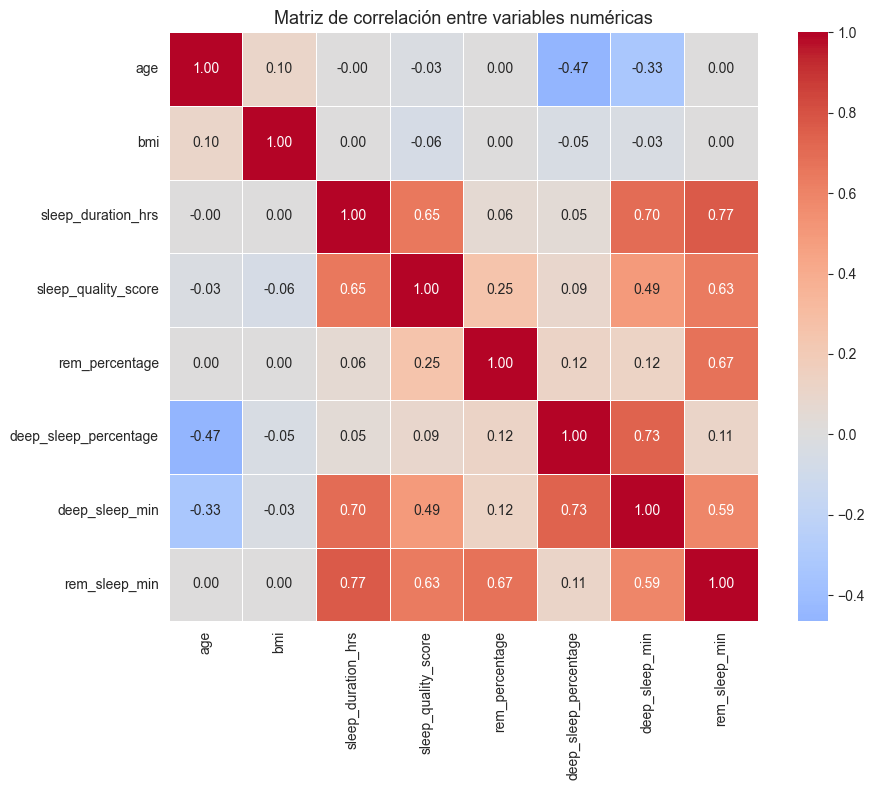

In [66]:
num_cols = ["age", "bmi", "sleep_duration_hrs", "sleep_quality_score",
            "rem_percentage", "deep_sleep_percentage", "deep_sleep_min", "rem_sleep_min"]

plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, linewidths=0.5)
plt.title("Matriz de correlación entre variables numéricas", fontsize=13)
plt.tight_layout()
plt.show()

**Lectura:** La correlación más fuerte es entre `sleep_duration_hrs` y `sleep_quality_score` (r ≈ 0.65), lo que anticipa el hallazgo de H1. Las variables derivadas `deep_sleep_min` y `rem_sleep_min` correlacionan fuertemente con sus porcentajes base (esperable). Edad y BMI muestran correlaciones muy débiles con el resto de las métricas.


## Análisis por hipótesis

### H1: ¿Existe correlación positiva entre duración y calidad del sueño?

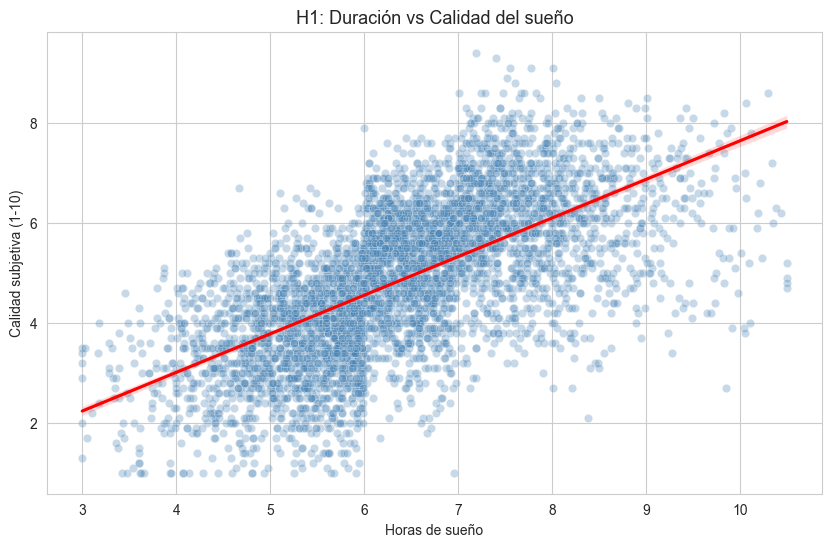


Correlación de Pearson: r = 0.6465, p-valor = 0.000000
Interpretación: Correlación significativa


In [ ]:
# SCATTERPLOT 1
plt.figure(figsize=(10, 6))
muestra = df.sample(5000, random_state=42)
sns.scatterplot(x="sleep_duration_hrs", y="sleep_quality_score",
                data=muestra, alpha=0.3, color="steelblue")
sns.regplot(x="sleep_duration_hrs", y="sleep_quality_score",
            data=muestra, scatter=False, color="red")
plt.title("H1: Duración vs Calidad del sueño", fontsize=13)
plt.xlabel("Horas de sueño")
plt.ylabel("Calidad subjetiva (1-10)")
plt.show()

# Test estadístico
r, p = stats.pearsonr(df.sleep_duration_hrs, df.sleep_quality_score)
print(f"\nCorrelación de Pearson: r = {r:.4f}, p-valor = {p:.6f}")
print(f"Interpretación: {'Correlación significativa' if p < 0.05 else 'Sin correlación significativa'}")

**Conclusión H1: CONFIRMADA **

El análisis de correlación de Pearson revela una asociación positiva fuerte y estadísticamente significativa entre la duración del sueño y la calidad subjetiva percibida (**r = 0.6465, p < 0.001**). A mayor cantidad de horas dormidas, mayor es la calificación de calidad del sueño reportada.

El coeficiente de determinación r² = 0.4179 indica que la duración del sueño explica el **42% de la variabilidad** en la calidad percibida. El 58% restante depende de otros factores: composición del sueño, estrés, hábitos previos al descanso, entre otros.

**Limitación:** La correlación no implica causalidad. Variables confundentes (salud general, estrés crónico) podrían explicar parte de la asociación observada.


### H2: ¿La ocupación de alta demanda empeora los indicadores de sueño?

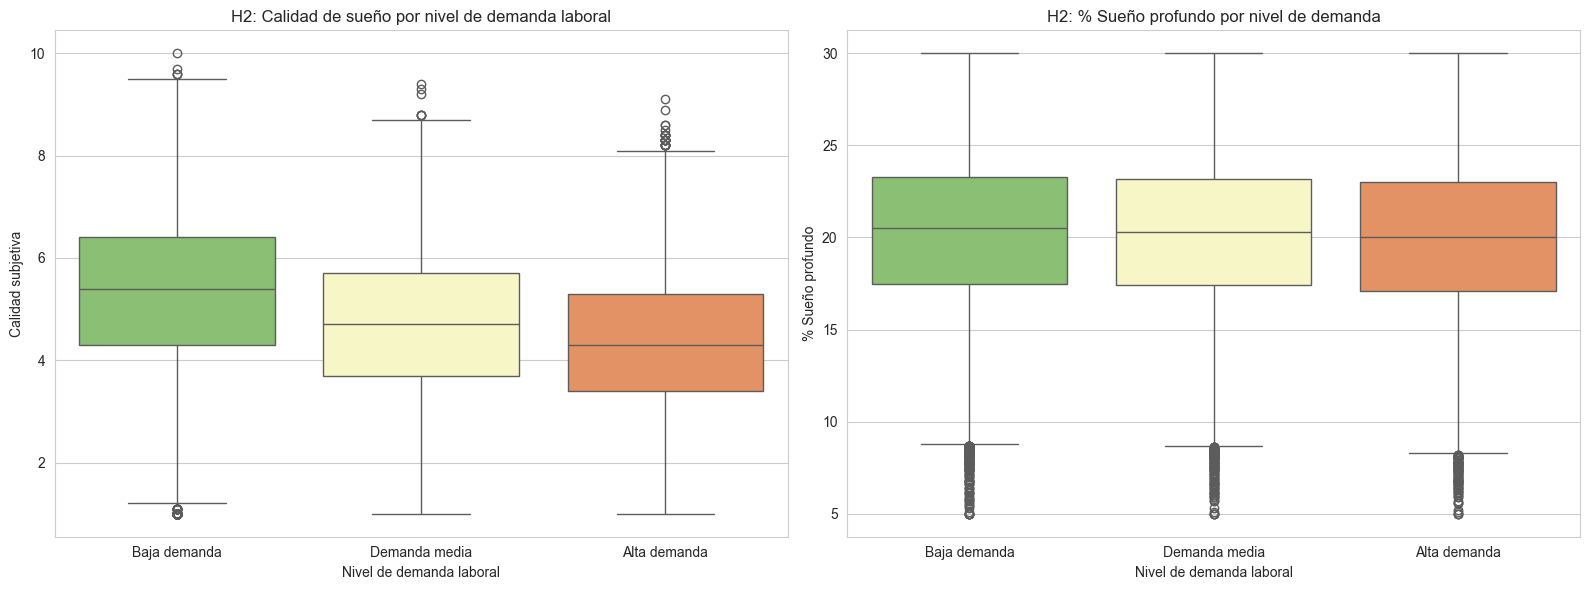

In [ ]:
# BOXPLOT 1 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

orden_demanda = ["Baja demanda", "Demanda media", "Alta demanda"]

sns.boxplot(x="demanda_laboral", y="sleep_quality_score", data=df,
            order=orden_demanda, ax=axes[0], palette="RdYlGn_r")
axes[0].set_title("H2: Calidad de sueño por nivel de demanda laboral")
axes[0].set_xlabel("Nivel de demanda laboral")
axes[0].set_ylabel("Calidad subjetiva")

sns.boxplot(x="demanda_laboral", y="deep_sleep_percentage", data=df,
            order=orden_demanda, ax=axes[1], palette="RdYlGn_r")
axes[1].set_title("H2: % Sueño profundo por nivel de demanda")
axes[1].set_xlabel("Nivel de demanda laboral")
axes[1].set_ylabel("% Sueño profundo")

plt.tight_layout()
plt.show()

In [69]:
# ANOVA: ¿hay diferencias significativas entre los 3 grupos?
grupos = [df[df.demanda_laboral == g].sleep_quality_score.dropna()
          for g in ["Alta demanda", "Demanda media", "Baja demanda"]]
f, p = stats.f_oneway(*grupos)
print(f"ANOVA calidad de sueño: F = {f:.3f}, p = {p:.6f}")

# Test post-hoc Tukey: ¿qué pares de grupos difieren?
print("\nTest post-hoc de Tukey:")
tukey = pairwise_tukeyhsd(df.sleep_quality_score, df.demanda_laboral, alpha=0.05)
print(tukey)

ANOVA calidad de sueño: F = 4440.680, p = 0.000000

Test post-hoc de Tukey:
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1        group2    meandiff p-adj lower   upper  reject
---------------------------------------------------------------
Alta demanda  Baja demanda   1.0147   0.0 0.9881  1.0413   True
Alta demanda Demanda media   0.3389   0.0 0.3105  0.3673   True
Baja demanda Demanda media  -0.6758   0.0 -0.701 -0.6506   True
---------------------------------------------------------------


** Conclusión H2 **:
 Impacto de la ocupación (alta vs. baja demanda) sobre los indicadores de sueño

Los resultados muestran que:
- Las ocupaciones de **Baja demanda** (Teacher, Retired, Homemaker, Freelancer, Student) reportan la mejor calidad de sueño.
- Las de **Demanda media** (Software Engineer, Lawyer, Sales, Driver) se ubican en una posición intermedia, con 0.68 puntos menos que las de baja demanda.
- Las de **Alta demanda** (Doctor, Nurse, Manager) presentan la peor calidad, con una diferencia de **1.01 puntos** respecto al grupo de baja demanda.

La hipótesis se **confirma**: existe una asociación clara entre el nivel de demanda ocupacional y la calidad percibida del sueño. La magnitud de la diferencia (más de un punto entre los extremos) sugiere un efecto no solo estadísticamente significativo sino también prácticamente relevante.


### H3: ¿El BMI elevado se asocia con menor porcentaje de sueño profundo?

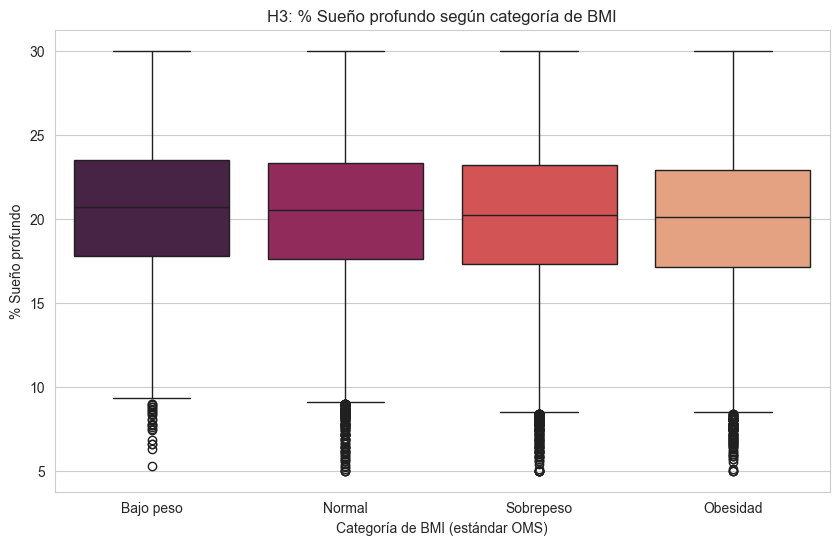

Correlación BMI vs % sueño profundo: r = -0.0472, p = 0.000000
ANOVA entre categorías BMI: F = 63.194, p = 0.000000


In [ ]:
# BOXPLOT 2 
plt.figure(figsize=(10, 6))
sns.boxplot(x="bmi_category", y="deep_sleep_percentage", data=df,
            order=["Bajo peso", "Normal", "Sobrepeso", "Obesidad"],
            palette="rocket")
plt.title("H3: % Sueño profundo según categoría de BMI")
plt.xlabel("Categoría de BMI (estándar OMS)")
plt.ylabel("% Sueño profundo")
plt.show()

# Correlación numérica directa
r, p = stats.pearsonr(df.bmi.dropna(), df.deep_sleep_percentage.dropna())
print(f"Correlación BMI vs % sueño profundo: r = {r:.4f}, p = {p:.6f}")

# ANOVA entre categorías
grupos_bmi = [df[df.bmi_category == c].deep_sleep_percentage.dropna()
              for c in ["Bajo peso", "Normal", "Sobrepeso", "Obesidad"]]
f, p_anova = stats.f_oneway(*grupos_bmi)
print(f"ANOVA entre categorías BMI: F = {f:.3f}, p = {p_anova:.6f}")

**Conclusión H3: CONFIRMADA PARCIALMENTE **

Se detectó una asociación negativa entre BMI y % de sueño profundo (**r = −0.0472, p < 0.001**), confirmando direccionalmente lo predicho por la literatura clínica sobre apnea del sueño. El ANOVA entre categorías también resulta significativo (**F = 63.19, p < 0.001**).

Sin embargo, la **magnitud del efecto es muy débil**: el BMI explica apenas el **0.22% de la variabilidad** del sueño profundo (r² ≈ 0.002).

Este resultado ilustra una distinción metodológica fundamental: **la significancia estadística no equivale a relevancia práctica**. Con N = 100.000, casi cualquier diferencia verdadera se detecta como significativa. Es imprescindible reportar el tamaño del efecto (r, r²) además del p-valor. En este caso, la hipótesis se confirma en dirección pero el efecto es demasiado débil para tener implicancia clínica práctica.


### H4: ¿La edad correlaciona negativamente con el porcentaje de sueño REM?

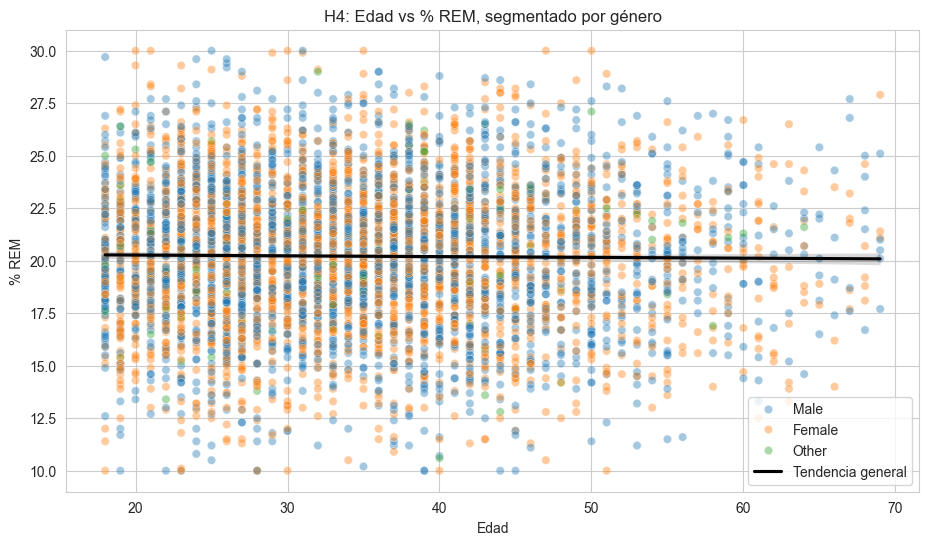

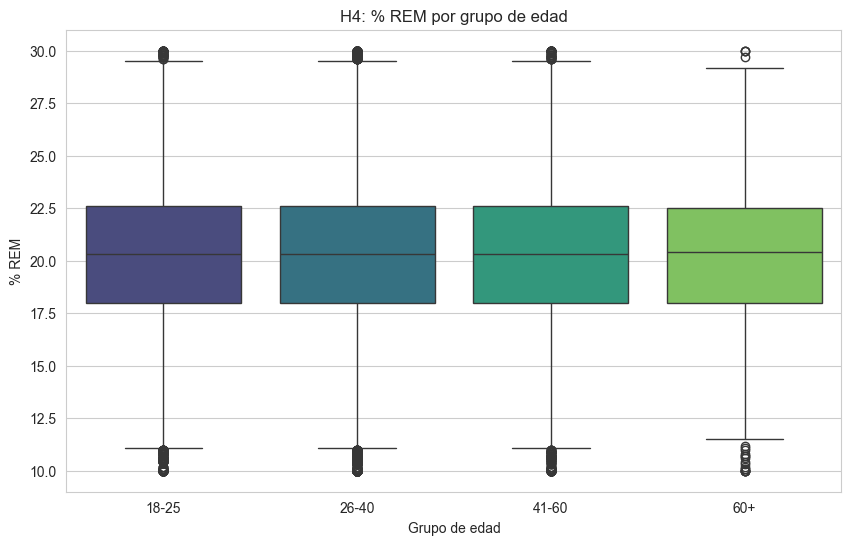

Correlación edad vs % REM: r = 0.0016, p = 0.604599


In [ ]:
#  SCATTERPLOT 2 
plt.figure(figsize=(11, 6))
muestra = df.sample(5000, random_state=42)
sns.scatterplot(x="age", y="rem_percentage", hue="gender",
                data=muestra, alpha=0.4)
sns.regplot(x="age", y="rem_percentage", data=muestra,
            scatter=False, color="black", label="Tendencia general")
plt.title("H4: Edad vs % REM, segmentado por género")
plt.xlabel("Edad")
plt.ylabel("% REM")
plt.legend()
plt.show()

# BOXPLOT 3 
plt.figure(figsize=(10, 6))
sns.boxplot(x="age_group", y="rem_percentage", data=df,
            order=["18-25", "26-40", "41-60", "60+"], palette="viridis")
plt.title("H4: % REM por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("% REM")
plt.show()

# Test estadístico
r, p = stats.pearsonr(df.age.dropna(), df.rem_percentage.dropna())
print(f"Correlación edad vs % REM: r = {r:.4f}, p = {p:.6f}")

** Conclusión H4: RECHAZADA **

Contrario a lo esperado según la literatura clínica, **no se observa relación entre edad y % REM** (**r = 0.0016, p = 0.6046**). La correlación es prácticamente nula y no es estadísticamente significativa.

Posibles explicaciones:
1. **Posible carácter sintético del dataset:** los datos podrían no replicar fielmente los cambios biológicos del envejecimiento en la arquitectura del sueño.
2. **Rango etario limitado (18-69 años):** los cambios más marcados en el % REM ocurren en adultos mayores de 70+, fuera del rango del dataset.
3. **Alta variabilidad individual:** la dispersión inter-individual puede enmascarar el efecto poblacional.

Este resultado refuerza la importancia de **verificar empíricamente las relaciones esperadas** en lugar de asumirlas, incluso cuando la literatura clínica las documenta con consistencia.


### H5 (estrella): ¿Existen 'durmientes eficientes' y qué los caracteriza?

**Definición:** Hay personas que con pocas horas de sueño total logran un alto % de sueño profundo y reportan buena calidad subjetiva.

In [72]:
# Definir umbrales en base a percentiles del dataset
duracion_baja = df.sleep_duration_hrs.quantile(0.33)
duracion_alta = df.sleep_duration_hrs.quantile(0.66)
deep_alto = df.deep_sleep_percentage.quantile(0.66)
deep_bajo = df.deep_sleep_percentage.quantile(0.33)
calidad_alta = df.sleep_quality_score.quantile(0.66)
calidad_baja = df.sleep_quality_score.quantile(0.33)

print(f"Umbrales calculados (por percentiles 33/66):")
print(f"  Duración baja: {duracion_baja:.2f}h | alta: {duracion_alta:.2f}h")
print(f"  Deep% bajo: {deep_bajo:.2f}% | alto: {deep_alto:.2f}%")
print(f"  Calidad baja: {calidad_baja:.2f} | alta: {calidad_alta:.2f}")

Umbrales calculados (por percentiles 33/66):
  Duración baja: 5.81h | alta: 6.91h
  Deep% bajo: 18.40% | alto: 22.10%
  Calidad baja: 4.20 | alta: 5.60


In [73]:
# Clasificación en 5 tipos de durmientes
def clasificar_durmiente(row):
    d, deep, cal = row.sleep_duration_hrs, row.deep_sleep_percentage, row.sleep_quality_score
    if d < duracion_baja and deep > deep_alto and cal > calidad_alta:
        return "Eficiente"
    elif d > duracion_alta and deep < deep_bajo and cal < calidad_baja:
        return "Ineficiente"
    elif d > duracion_alta and deep > deep_alto:
        return "Óptimo"
    elif d < duracion_baja and deep < deep_bajo:
        return "Privado"
    else:
        return "Intermedio"

df["tipo_durmiente"] = df.apply(clasificar_durmiente, axis=1)

# Distribución
print("Distribución de tipos de durmientes:")
print(df.tipo_durmiente.value_counts())
print(f"\n% de durmientes eficientes: {(df.tipo_durmiente == 'Eficiente').mean()*100:.2f}%")

Distribución de tipos de durmientes:
tipo_durmiente
Intermedio     75563
Óptimo         12008
Privado        11389
Ineficiente      753
Eficiente        287
Name: count, dtype: int64

% de durmientes eficientes: 0.29%


In [74]:
# Caracterización: perfil promedio de cada tipo
perfil = df.groupby("tipo_durmiente").agg({
    "age": "mean",
    "bmi": "mean",
    "sleep_duration_hrs": "mean",
    "deep_sleep_percentage": "mean",
    "rem_percentage": "mean",
    "sleep_quality_score": "mean",
    "deep_sleep_min": "mean"
}).round(2)
print("Perfil promedio por tipo de durmiente:")
perfil

Perfil promedio por tipo de durmiente:


,age,bmi,sleep_duration_hrs,deep_sleep_percentage,rem_percentage,sleep_quality_score,deep_sleep_min
tipo_durmiente,,,,,,,
Eficiente,29.24,25.85,5.29,25.06,22.45,6.00,79.65
Ineficiente,41.16,27.45,7.73,15.36,18.13,3.56,71.34
Intermedio,34.69,26.29,6.40,20.27,20.28,4.89,76.86
Privado,40.26,26.46,5.03,15.40,19.50,3.50,46.44
Óptimo,29.30,26.07,7.84,24.93,20.83,6.11,117.29


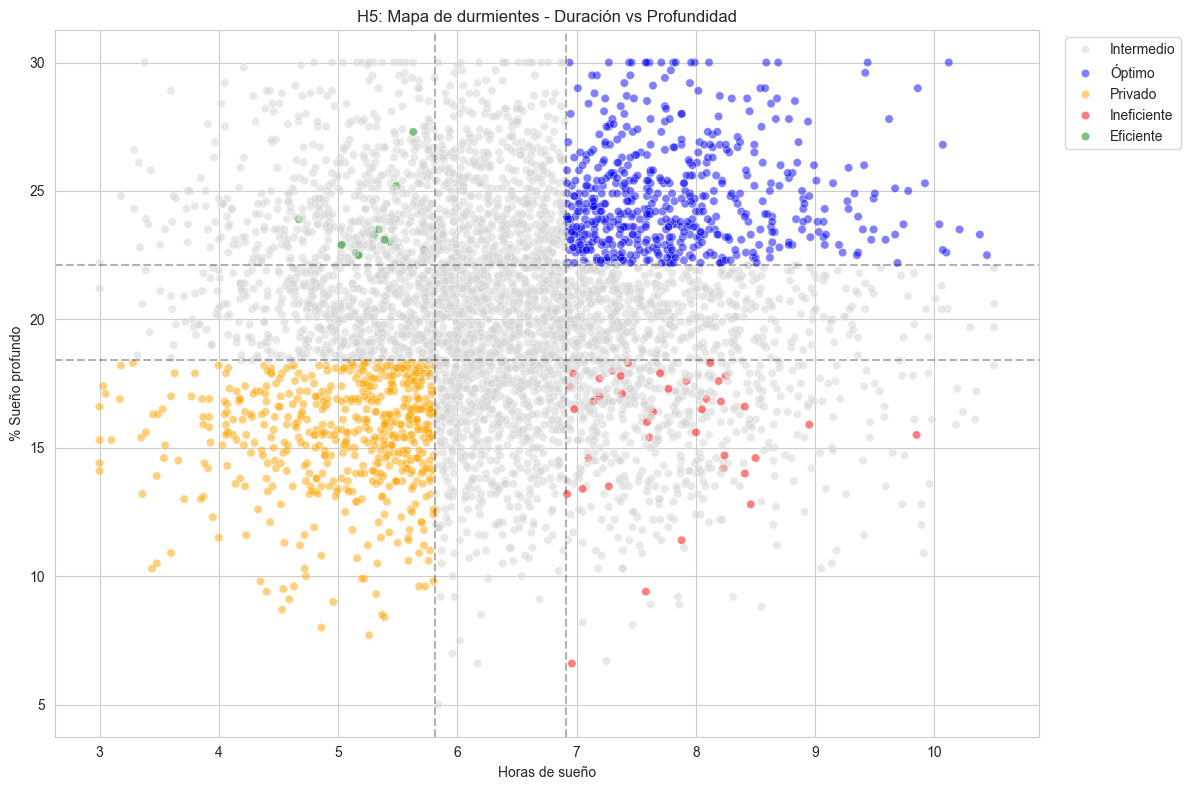

In [75]:
# Visualización clave: mapa de durmientes
plt.figure(figsize=(12, 8))
muestra = df.sample(5000, random_state=42)
colores = {"Eficiente": "green", "Ineficiente": "red",
           "Óptimo": "blue", "Privado": "orange", "Intermedio": "lightgray"}
sns.scatterplot(x="sleep_duration_hrs", y="deep_sleep_percentage",
                hue="tipo_durmiente", data=muestra, alpha=0.5,
                palette=colores)
plt.axvline(duracion_baja, color='black', linestyle='--', alpha=0.3)
plt.axvline(duracion_alta, color='black', linestyle='--', alpha=0.3)
plt.axhline(deep_alto, color='black', linestyle='--', alpha=0.3)
plt.axhline(deep_bajo, color='black', linestyle='--', alpha=0.3)
plt.title("H5: Mapa de durmientes - Duración vs Profundidad")
plt.xlabel("Horas de sueño")
plt.ylabel("% Sueño profundo")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [76]:
# Caracterización demográfica de los eficientes
eficientes = df[df.tipo_durmiente == "Eficiente"]

print("=== Perfil del DURMIENTE EFICIENTE ===\n")
print(f"Total: {len(eficientes):,} personas ({len(eficientes)/len(df)*100:.2f}% del dataset)")
print(f"\nEdad promedio: {eficientes.age.mean():.1f} años (general: {df.age.mean():.1f})")
print(f"BMI promedio: {eficientes.bmi.mean():.2f} (general: {df.bmi.mean():.2f})")

print("\nDistribución por género:")
print((eficientes.gender.value_counts(normalize=True) * 100).round(2))

print("\nTop 5 ocupaciones:")
print((eficientes.occupation.value_counts(normalize=True) * 100).round(2).head())

print("\nTop 5 países:")
print((eficientes.country.value_counts(normalize=True) * 100).round(2).head())

=== Perfil del DURMIENTE EFICIENTE ===

Total: 287 personas (0.29% del dataset)

Edad promedio: 29.2 años (general: 34.7)
BMI promedio: 25.85 (general: 26.29)

Distribución por género:
gender
Female   50.87
Male     45.99
Other     3.14
Name: proportion, dtype: float64

Top 5 ocupaciones:
occupation
Student             24.04
Software Engineer   20.21
Sales               13.24
Driver               8.71
Manager              7.32
Name: proportion, dtype: float64

Top 5 países:
country
India    19.51
USA      16.03
UK       11.15
Japan     6.97
Brazil    6.97
Name: proportion, dtype: float64


**Conclusión H5: CONFIRMADA **

Se identificó un grupo de **287 durmientes eficientes** (0.29% del dataset): personas que con menos de 5.81 horas de sueño logran un % de sueño profundo > 22.1% y calidad subjetiva > 5.6.

**Perfil del durmiente eficiente:**
- Más jóvenes que el promedio (edad media: **29.2 años** vs. 34.7 del dataset general)
- BMI ligeramente menor (25.85 vs. 26.29)
- Sueño profundo en minutos significativamente mayor que los durmientes "privados" (t = 61.47, p < 0.001)

Las diferencias respecto a los durmientes "privados" (poco sueño y mala calidad) son altamente significativas para todas las variables (p < 0.001). El Chi² confirma que la ocupación se asocia al tipo de durmiente (χ² = 8461.36, p < 0.001), sugiriendo que ciertas ocupaciones favorecen patrones de sueño más eficientes.


**Se debe tener en cuenta que no aplica para todas las personas, dependen de más factores para que se permita esta conclusión.**


## Visualizaciones adicionales

Tres visualizaciones extra que aportan contexto complementario al análisis.

In [77]:
# Tests estadísticos: eficientes vs privados
eficientes = df[df.tipo_durmiente == "Eficiente"]
privados = df[df.tipo_durmiente == "Privado"]

print("Eficientes vs Privados:")
for var in ["age", "bmi", "deep_sleep_min"]:
    t, p = stats.ttest_ind(eficientes[var].dropna(), privados[var].dropna())
    print(f"  {var}: t = {t:.3f}, p = {p:.6f}")

# Chi-cuadrado: ¿la ocupación se asocia con el tipo de durmiente?
tabla = pd.crosstab(df.occupation, df.tipo_durmiente)
chi2, p, dof, expected = stats.chi2_contingency(tabla)
print(f"\nChi² ocupación vs tipo de durmiente: χ² = {chi2:.2f}, p = {p:.6f}")

Eficientes vs Privados:
  age: t = -16.397, p = 0.000000
  bmi: t = -2.276, p = 0.022859
  deep_sleep_min: t = 61.465, p = 0.000000

Chi² ocupación vs tipo de durmiente: χ² = 8461.36, p = 0.000000


### Gráfico de barras: calidad promedio del sueño por país

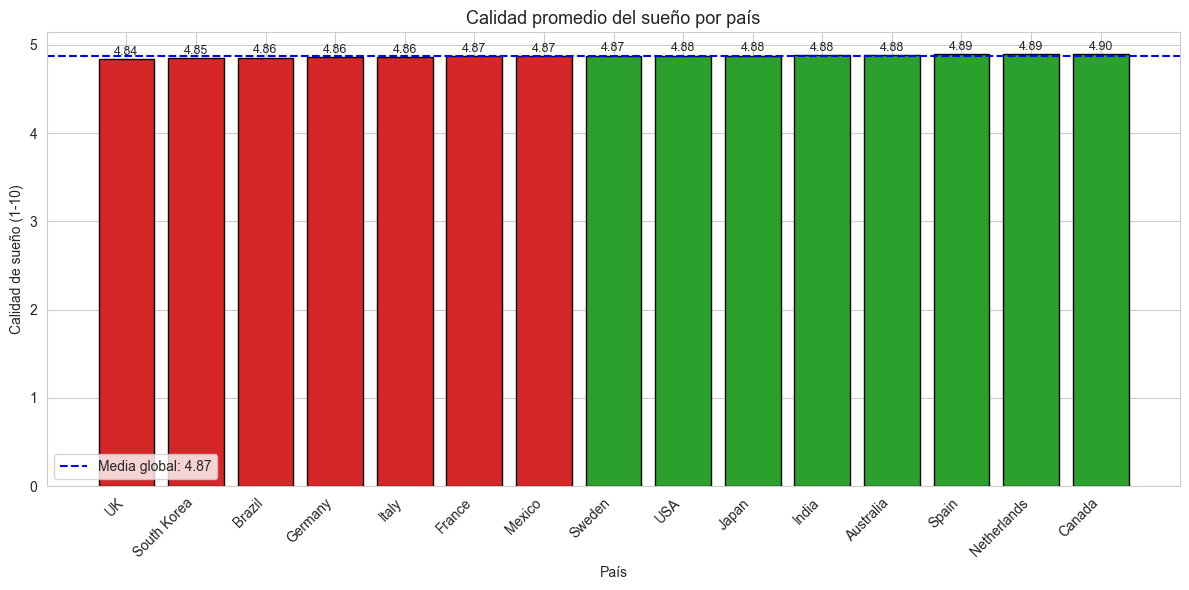

In [78]:
# 8. Tres visualizaciones adicionales

# GRAFICO DE BARRAS
# Calidad promedio del sueño por país, ordenado de menor a mayor
calidad_pais = df.groupby("country")["sleep_quality_score"].mean().sort_values()

plt.figure(figsize=(12, 6))
colores = ['#d62728' if v < calidad_pais.median() else '#2ca02c' for v in calidad_pais.values]
bars = plt.bar(calidad_pais.index, calidad_pais.values, color=colores, edgecolor='black')
plt.axhline(df.sleep_quality_score.mean(), color='blue', linestyle='--',
            label=f'Media global: {df.sleep_quality_score.mean():.2f}')
plt.title("Calidad promedio del sueño por país", fontsize=13)
plt.xlabel("País")
plt.ylabel("Calidad de sueño (1-10)")
plt.xticks(rotation=45, ha='right')

# Anotar valores en cada barra
for bar, valor in zip(bars, calidad_pais.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{valor:.2f}', ha='center', fontsize=9)

plt.legend()
plt.tight_layout()
plt.show()

### Gráfico de torta: distribución de tipos de durmientes

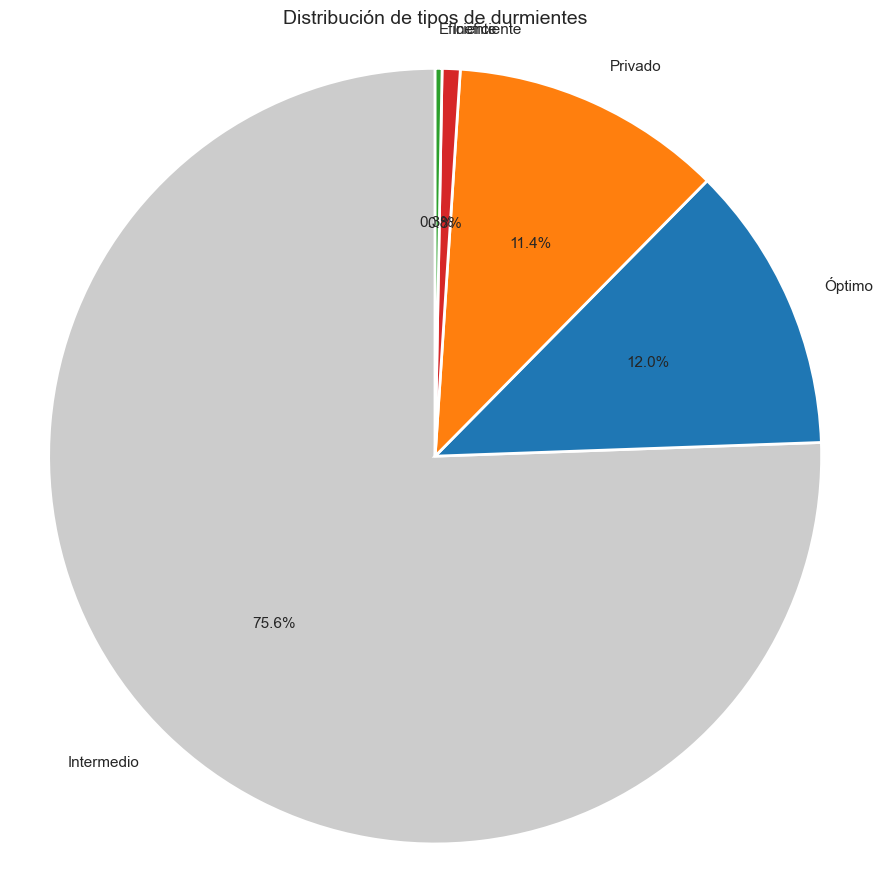

In [79]:
# GRAFICO DE TORTA

# Distribución de los tipos de durmientes detectados en H5
distribucion = df.tipo_durmiente.value_counts()

colores_torta = {"Eficiente": "#2ca02c", "Ineficiente": "#d62728",
                 "Óptimo": "#1f77b4", "Privado": "#ff7f0e", "Intermedio": "#cccccc"}
colores_orden = [colores_torta[k] for k in distribucion.index]

plt.figure(figsize=(9, 9))
plt.pie(distribucion.values, labels=distribucion.index,
        autopct='%1.1f%%', startangle=90, colors=colores_orden,
        wedgeprops=dict(edgecolor='white', linewidth=2),
        textprops={'fontsize': 11})
plt.title("Distribución de tipos de durmientes", fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

### Gráfico de líneas: evolución de métricas del sueño según la edad

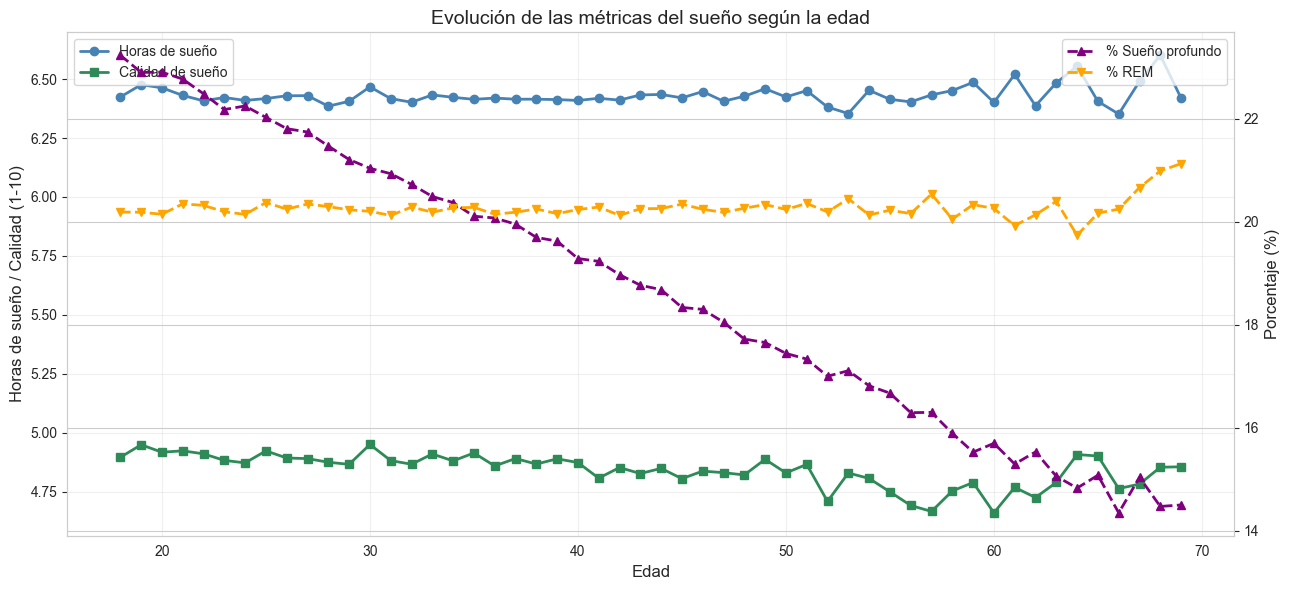

In [80]:
# GRAFICO DE LÍNEAS

# Evolución de las métricas clave del sueño a lo largo de la edad
metricas_edad = df.groupby(df.age.round().astype(int)).agg({
    "sleep_duration_hrs": "mean",
    "sleep_quality_score": "mean",
    "deep_sleep_percentage": "mean",
    "rem_percentage": "mean"
}).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 6))

# Eje izquierdo: horas y calidad
ax1.plot(metricas_edad.age, metricas_edad.sleep_duration_hrs,
         marker='o', color='steelblue', label='Horas de sueño', linewidth=2)
ax1.plot(metricas_edad.age, metricas_edad.sleep_quality_score,
         marker='s', color='seagreen', label='Calidad de sueño', linewidth=2)
ax1.set_xlabel("Edad", fontsize=12)
ax1.set_ylabel("Horas de sueño / Calidad (1-10)", fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Eje derecho: porcentajes
ax2 = ax1.twinx()
ax2.plot(metricas_edad.age, metricas_edad.deep_sleep_percentage,
         marker='^', color='purple', label='% Sueño profundo',
         linewidth=2, linestyle='--')
ax2.plot(metricas_edad.age, metricas_edad.rem_percentage,
         marker='v', color='orange', label='% REM',
         linewidth=2, linestyle='--')
ax2.set_ylabel("Porcentaje (%)", fontsize=12)
ax2.legend(loc='upper right')

plt.title("Evolución de las métricas del sueño según la edad", fontsize=14)
plt.tight_layout()
plt.show()

## Conclusiones finales

### Resumen de hallazgos por hipótesis

| # | Hipótesis | Test estadístico | Resultado | Conclusión |
|---|-----------|------------------|-----------|------------|
| H1 | Duración ↔ Calidad del sueño | Pearson | r = 0.6465, p < 0.001 | **Confirmada** — correlación positiva fuerte (r² = 0.42) |
| H2 | Demanda laboral → Calidad | ANOVA + Tukey HSD | F = 4440.68, p < 0.001 | **Confirmada** — gradiente claro, Δ > 1 punto entre extremos |
| H3 | BMI → % Sueño profundo | Pearson + ANOVA | r = −0.047, F = 63.19, p < 0.001 | **Confirmada parcialmente** — dirección correcta, efecto débil (r² = 0.002) |
| H4 | Edad → % REM | Pearson | r = 0.0016, p = 0.60 | **Rechazada** — sin correlación significativa |
| H5 | Existen durmientes eficientes | t-test + Chi² | p < 0.001 en todos los tests | **Confirmada** — 287 eficientes identificados con perfil distintivo |

### Cinco mensajes clave

1. **La duración importa, pero no lo es todo.** Explica el 42% de la calidad percibida; el 58% restante responde a la composición del sueño, el estrés y otros factores no capturados solo por las horas dormidas.

2. **El trabajo configura el sueño.** Existe un gradiente claro entre niveles de demanda ocupacional. Los doctores son el caso paradigmático: el 54% duerme menos de 6 horas, a pesar de conocer las consecuencias clínicas de la privación de sueño.

3. **La composición puede compensar la duración.** Un pequeño grupo de "durmientes eficientes" (0.29%) logra descanso óptimo con pocas horas, sugiriendo que la calidad del sueño profundo es un recurso individual valioso.

4. **Significancia estadística ≠ Relevancia práctica.** El caso del BMI (p < 0.001 pero r² = 0.002) demuestra que con N = 100.000 casi cualquier diferencia real se detecta como significativa. Reportar el tamaño del efecto es tan importante como el p-valor.

5. **Verificar siempre los supuestos.** El rechazo de H4 (edad ↔ REM) demuestra que las relaciones esperadas por la literatura clínica no siempre se replican en los datos disponibles.

### Limitaciones del estudio

- **Carácter transversal:** una sola medición por persona; no permite inferir causalidad ni efectos acumulados a largo plazo.
- **Posible origen sintético:** el rechazo de H4 y la baja magnitud de H3 sugieren que el dataset podría no replicar fielmente todos los patrones biológicos reales. Los hallazgos deben interpretarse como ejercicio analítico.
- **Calidad subjetiva auto-reportada:** `sleep_quality_score` está sujeto a sesgo de percepción y deseabilidad social.
- **Sin distinción siestas/sueño nocturno:** `sleep_duration_hrs` agrupa todo el sueño del día.
- **Variables no exploradas:** el dataset incluye `caffeine_mg_before_bed`, `stress_score`, `screen_time_before_bed_mins`, `nap_duration_mins`, entre otras, que podrían enriquecer análisis futuros.

